# GRPO + LoRA Training on GraphForge OpenENV

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1lLad2y39zfGQRNtwyCGnMlKd6M1acx-0?usp=sharing)

Train **Qwen2.5-3B-Instruct** with **GRPO** (Group Relative Policy Optimization) and **LoRA** against the GraphForge AST environment hosted as an OpenEnv Space at [`TarunGopinath/OpenENV-GraphForge`](https://huggingface.co/spaces/TarunGopinath/OpenENV-GraphForge).

**Stack**

- [`openenv-core`](https://github.com/openenv/openenv-core) — environment client (`EnvClient`), pydantic schemas, episode protocol.
- [`unsloth`](https://github.com/unslothai/unsloth) — `FastLanguageModel` for 2× faster training and ~70% lower VRAM, so the whole training loop fits in a single Colab GPU.
- `peft` — LoRA adapters, plus `model.disable_adapter()` to get the reference policy with no extra memory.
- Custom GRPO loop (TRL's `GRPOTrainer.rollout_func` is still rough for stateful multi-turn envs as of TRL `main`; the loop here mirrors the same math but keeps full control over the agent / tool-use rollout).

**What this notebook does**

1. Connect to the hosted GraphForge Space (`EnvClient`).
2. Load Qwen2.5-3B-Instruct via Unsloth + attach LoRA.
3. Evaluate the **untrained** model on a held-out set of seeds → baseline rewards.
4. Train with GRPO: G rollouts per task, group-relative advantages, clipped policy gradient + KL to the frozen base (LoRA disabled = ref).
5. Re-evaluate on the same held-out seeds → trained rewards.
6. Plot **loss going down** + **cumulative reward going up**.

**Hardware.** Designed to run on Colab. On a local trained with 1 H100 box

---

**GRPO recap** (DeepSeek-Math). For each task `s`, sample `G` rollouts `{τ_1, …, τ_G}` from the current policy. Compute episode rewards `R_i`. Within the group, normalize:

$$ A_i = (R_i - \text{mean}(R)) / (\text{std}(R) + \epsilon) $$

Loss per assistant token (PPO-clipped + KL to ref):

$$ \mathcal{L} = -\min\!\left(\rho_t A_i,\, \text{clip}(\rho_t, 1-\epsilon, 1+\epsilon)\, A_i\right) + \beta\, \mathrm{KL}(\pi_\theta \| \pi_{\text{ref}}) $$

where `ρ_t = exp(log π_θ(a_t|s) − log π_old(a_t|s))`. No critic — that's the point of GRPO.


## 1. Install

In [ ]:
# --- Install ---
# unsloth[colab-new] picks the right torch / xformers / triton wheel for the runtime.
# We pin transformers to a known-good range; openenv-core ships the env client.
%pip install -q --upgrade pip
%pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
%pip install -q --no-deps "trl<0.16" peft accelerate bitsandbytes
%pip install -q openenv-core "transformers>=4.45,<5.0" "huggingface-hub<1.0" \
                "datasets>=2.16" matplotlib pandas tqdm


## 2. Imports & config

In [1]:
from __future__ import annotations

import os
# IMPORTANT: pin to a single GPU BEFORE torch is imported. On a multi-GPU box
# (e.g. 2× H100), HF accelerate / Unsloth's auto device_map will otherwise
# shard the model and you'll get "tensors on cuda:0 and cuda:1" during generation.
# If you change this, restart the kernel — env vars only matter at torch-init time.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import re, json, ast, math, time, random, copy
from typing import Any, Dict, List, Literal, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
\
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from pydantic import Field
from openenv.core import Action, Observation, State, EnvClient
from openenv.core.env_client import StepResult

# Unsloth must be imported BEFORE transformers / peft for the patches to apply.
from unsloth import FastLanguageModel
from transformers import AutoTokenizer
from peft import LoraConfig, TaskType

torch.set_float32_matmul_precision("high")

# ----------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
SPACE_URL  = "https://tarungopinath-openenv-graphforge.hf.space"
DEVICE     = "cuda:0"
DTYPE      = torch.bfloat16

# ----------------------------------------------------------------------
# GRPO hyperparameters
# ----------------------------------------------------------------------
NUM_GRPO_STEPS  = 25       # outer optimization steps
GROUP_SIZE      = 8        # G — rollouts per task
MAX_TURNS       = 6       # cap on agent steps per episode
MAX_NEW_TOKENS  = 10000      # per assistant turn (one tool call ~ 100-300 tokens)
MAX_SEQ_LEN     = 25000     # cap for Unsloth model loader (prompt + completion)
TEMPERATURE     = 1.0      # rollout sampling temperature (exploration)
EVAL_TEMPERATURE= 0.7      # eval sampling temperature (lower variance)
TOP_P           = 0.95
LR              = 1e-5
KL_COEF         = 0.04     # β — KL to frozen base
CLIP_EPS        = 0.2      # PPO clipping ε
MAX_GRAD_NORM   = 1.0

# Eval seeds — fixed so before/after are comparable
EVAL_SEEDS  = [101, 202, 303, 404, 505, 606]
TRAIN_SEEDS = [s for s in range(1, 200) if s not in EVAL_SEEDS]

# Where we save artifacts
OUT_DIR = "./grpo_outputs_2"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# Runtime info — useful in Colab so judges can see which GPU was used
# ----------------------------------------------------------------------
print(f"torch={torch.__version__}  cuda={torch.cuda.is_available()}  "
      f"device_count={torch.cuda.device_count()}  "
      f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES', 'unset')}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i}  {p.name}  {p.total_memory / 1e9:.0f}GB")

if torch.cuda.device_count() > 1:
    print("\n  ! More than one GPU is visible to torch. If you see device-mismatch errors")
    print("    during generation, RESTART THE KERNEL and re-run from the top — the")
    print("    CUDA_VISIBLE_DEVICES env var only takes effect before torch is imported.")

if torch.cuda.is_available():
    _vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if _vram_gb < 20:
        print(f"\n  ! Detected {_vram_gb:.0f}GB VRAM — consider GROUP_SIZE=2, MAX_TURNS=4 if you OOM.")


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
torch=2.7.1+cu126  cuda=True  device_count=1  CUDA_VISIBLE_DEVICES=0
  cuda:0  NVIDIA H100 PCIe  85GB


## 3. Environment client

Same typed `Action` / `Observation` / `EnvClient` subclass as the simulation notebook. The Space ships a stale `client.py` so we redefine inline.

In [2]:
AST_ACTION_TYPES = Literal[
    "get_neighbors", "add_node", "modify_node", "delete_node", "submit",
]


class ASTActionResult(Observation):
    success: bool = False
    action_type: str = ""
    message: str = ""
    added_node_ids: List[str] = Field(default_factory=list)


class ASTAction(Action):
    action_type: AST_ACTION_TYPES
    parameters: Dict[str, Any] = Field(default_factory=dict)


class ASTObservation(Observation):
    episode_id: str = ""
    timestep: int = 0
    query: str = ""
    central_node: str = ""
    context_nodes: Dict[str, Any] = Field(default_factory=dict)
    context_edges: List[Dict[str, Any]] = Field(default_factory=list)
    not_found_nodes: List[str] = Field(default_factory=list)
    mutations_so_far: List[Dict[str, Any]] = Field(default_factory=list)
    last_action_result: Optional[ASTActionResult] = None
    available_actions: List[str] = Field(default_factory=list)


class ASTState(State):
    pass


class GraphForgeASTEnv(EnvClient[ASTAction, ASTObservation, ASTState]):
    """WebSocket client for the GraphForge AST-query environment."""

    def _step_payload(self, action: ASTAction) -> Dict[str, Any]:
        return action.model_dump()

    def _parse_result(self, payload: Dict[str, Any]) -> StepResult[ASTObservation]:
        obs_data = payload.get("observation", payload)
        obs = ASTObservation.model_validate(obs_data)
        if "done" in payload:
            obs.done = bool(payload["done"])
        if isinstance(payload.get("reward"), (int, float)):
            obs.reward = payload["reward"]
        return StepResult(observation=obs, reward=obs.reward, done=obs.done)

    def _parse_state(self, payload: Dict[str, Any]) -> ASTState:
        state_data = payload.get("state", payload)
        return ASTState.model_validate(state_data)

## 4. Tool schema & system prompt

OpenAI-style function specs that Qwen 2.5's chat template understands via `tools=`.

In [3]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_neighbors",
            "description": (
                "Fetch neighboring nodes/edges of a node. Use to expand context "
                "before mutating. Only request node IDs already in your context."
            ),
            "parameters": {
                "type": "object",
                "properties": {"node_id": {"type": "string"}},
                "required": ["node_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "add_node",
            "description": "ADD mutation: introduce a new function or class.",
            "parameters": {
                "type": "object",
                "properties": {
                    "node_id":   {"type": "string"},
                    "parent_id": {"type": "string"},
                    "child_ids": {"type": "array", "items": {"type": "string"}},
                    "code":      {"type": "string"},
                    "reasoning": {"type": "string"},
                },
                "required": ["node_id", "code", "reasoning"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "modify_node",
            "description": "MODIFY mutation: full updated source for an existing node.",
            "parameters": {
                "type": "object",
                "properties": {
                    "node_id":   {"type": "string"},
                    "code":      {"type": "string"},
                    "reasoning": {"type": "string"},
                },
                "required": ["node_id", "code", "reasoning"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "delete_node",
            "description": "DELETE mutation: remove an existing node.",
            "parameters": {
                "type": "object",
                "properties": {
                    "node_id":   {"type": "string"},
                    "reasoning": {"type": "string"},
                },
                "required": ["node_id", "reasoning"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "submit",
            "description": "Submit final answer once all required mutations are recorded.",
            "parameters": {"type": "object", "properties": {}, "required": []},
        },
    },
]

SYSTEM_PROMPT = """\
You are an AST-driven code evolution agent operating on a real Python codebase.

Strategy:
1. Read the task and the initial context (node source code + edges) carefully.
2. Call get_neighbors on nodes already in your context to expand if needed.
   Do NOT invent node IDs - only request IDs visible in your current context.
3. Record required mutations using add_node, modify_node, or delete_node.
   - add_node / modify_node: provide complete, runnable Python source.
   - Order ADDs before any MODIFY/DELETE that depend on them.
4. Call submit when done.

Always emit tool calls in the standard <tool_call>{...}</tool_call> format.
Be efficient - prefer fewer, higher-quality mutations over many small ones.
"""

## 5. Load Qwen2.5-3B with Unsloth + attach LoRA

Unsloth's `FastLanguageModel.from_pretrained` returns a model wrapped with custom Triton kernels (~2× faster, ~70% less VRAM, no accuracy loss). We then attach LoRA via `FastLanguageModel.get_peft_model` — this internally uses `peft`, so `model.disable_adapter()` still works as our reference policy (no extra memory).

Note: `fast_inference=False` here — we want the standard generation path so we can extract per-token logits during rollout (`output_logits=True`). vLLM-style fast inference doesn't expose those.


In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LEN,
    dtype           = DTYPE,
    load_in_4bit    = False,        # full BF16 — Qwen2.5-3B fits comfortably
    full_finetuning = False,
    fast_inference  = False,        # we need raw logits during rollout
    device_map      = {"": 0},      # pin entire model to a single GPU (no sharding)
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Attach LoRA. Unsloth's wrapper picks the right target_modules for the architecture
# but we name them explicitly to be reproducible.
model = FastLanguageModel.get_peft_model(
    model,
    r                = 32,
    lora_alpha       = 64,
    lora_dropout     = 0.05,
    target_modules   = ["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
    bias             = "none",
    use_gradient_checkpointing = "unsloth",   # Unsloth's impl — extra VRAM savings
    random_state     = 3407,
)

# Belt-and-suspenders: even if device_map didn't pin everything (e.g. Unsloth keeps a
# CPU-side meta tensor for the embedding), force every parameter onto DEVICE.
model = model.to(DEVICE)

# Verify the model is actually on a single device — fail loudly if not.
_devices = {p.device for p in model.parameters()}
print(f"Model parameters live on: {_devices}")
assert all(d.type == "cuda" and d.index == 0 for d in _devices), (
    f"Model is split across devices {_devices}. Restart the kernel with "
    "CUDA_VISIBLE_DEVICES=0 set before importing torch."
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")
print(f"Memory after model load: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 PCIe. Num GPUs = 1. Max memory: 79.097 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.69it/s]


unsloth/Qwen2.5-3B-Instruct does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Model parameters live on: {device(type='cuda', index=0)}
trainable params: 59,867,136 / 3,145,805,824  (1.90%)
Memory after model load: 6.45 GB


## 6. Helpers — tool-call parsing, observation formatting

Same parsers as the simulation notebook.

In [5]:
TOOL_CALL_RE = re.compile(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", re.DOTALL)
SPECIAL_RE   = re.compile(r"<\|.*?\|>")


def parse_tool_calls(text: str) -> List[Dict[str, Any]]:
    calls = []
    for m in TOOL_CALL_RE.finditer(text):
        try:
            obj = json.loads(m.group(1))
        except json.JSONDecodeError:
            continue
        if "name" not in obj:
            continue
        args = obj.get("arguments", {})
        if isinstance(args, str):
            try:
                args = json.loads(args)
            except json.JSONDecodeError:
                args = {}
        calls.append({"name": obj["name"], "arguments": args})
    return calls


def strip_special(text: str) -> str:
    return SPECIAL_RE.sub("", text).strip()


def obs_to_user_text(obs: ASTObservation) -> str:
    parts = [
        f"TASK: {obs.query}",
        f"CENTRAL NODE: {obs.central_node}",
        "",
        f"CONTEXT NODES ({len(obs.context_nodes)}):",
        json.dumps(list(obs.context_nodes.keys()), indent=2),
        "",
        "NODE DETAILS:",
        json.dumps(obs.context_nodes, indent=2),
        "",
        "EDGES:",
        json.dumps(obs.context_edges, indent=2),
    ]
    if obs.not_found_nodes:
        parts += ["", f"NOT FOUND - do not request again: {json.dumps(obs.not_found_nodes)}"]
    if obs.mutations_so_far:
        parts += [
            "",
            f"MUTATIONS RECORDED ({len(obs.mutations_so_far)}):",
            json.dumps(
                [{"type": m.get("type"), "node_id": m.get("node_id")}
                 for m in obs.mutations_so_far],
                indent=2,
            ),
        ]
    parts += ["", "Analyze the task and proceed."]
    return "\n".join(parts)


def tool_result_text(obs: ASTObservation, prev_count: int) -> str:
    r = obs.last_action_result
    msg = (r.message if r else "Done.") or "Done."
    if r and r.added_node_ids:
        new_data = {nid: obs.context_nodes.get(nid, {}) for nid in r.added_node_ids}
        msg += f"\nNew node details:\n{json.dumps(new_data, indent=2)}"
    cur = len(obs.context_nodes)
    msg += f"\nContext now has {cur} nodes (+{cur - prev_count})."
    return msg


def diagnose_mutation(mutation: Dict[str, Any]) -> Dict[str, Any]:
    """Static facts about one mutation's code field — used for reward shaping."""
    code = mutation.get("code") or ""
    out = {"parses": None, "n_funcs": 0, "n_classes": 0, "loc": code.count("\n") + 1 if code else 0}
    if mutation.get("type") == "DELETE" or not code:
        out["parses"] = (mutation.get("type") == "DELETE")
        return out
    try:
        tree = ast.parse(code)
        out["parses"] = True
        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                out["n_funcs"] += 1
            elif isinstance(node, ast.ClassDef):
                out["n_classes"] += 1
    except SyntaxError:
        out["parses"] = False
    return out


def shape_reward(env_reward: float, final_obs: ASTObservation) -> float:
    """Add small dense bonuses on top of the env reward to densify the signal.

    Rationale: with G=4 rollouts on a single seed and a ~3B base model, the env's
    final reward can frequently be 0 across the entire group → zero variance →
    zero advantage → no learning. Light shaping fixes that without changing the
    sign of what's good vs bad.
    """
    r = float(env_reward) if env_reward is not None else 0.0
    muts = list(final_obs.mutations_so_far)
    if not muts:
        return r - 0.5  # explicit penalty for submitting with nothing recorded
    n_parse_ok = sum(1 for m in muts if diagnose_mutation(m)["parses"])
    parse_rate = n_parse_ok / len(muts)
    shaped = (
        r
        + 0.10 * len(muts)            # reward producing real mutations
        + 0.20 * parse_rate           # reward syntactically valid Python
        - 0.05 * (len(muts) - n_parse_ok)  # penalty per parse failure
    )
    return shaped

## 7. Rollout: generate one episode + collect log-probs

For each assistant turn we record: the prompt token IDs (everything before generation), the completion token IDs (what the model produced), and the **per-token log-probability under the policy at sampling time** (`old_log_probs`). These are exactly what GRPO needs to compute the importance ratio later.

We use `output_logits=True` (raw model logits, ignoring temperature/top-p processing) so that `old_log_probs` represent the policy distribution `π_θ`, not the temperature-warped sampling distribution. This matches the standard PPO formulation.

In [6]:
@torch.no_grad()
def rollout(env, *, seed: int, do_sample: bool, temperature: float,
            max_turns: int = MAX_TURNS, verbose: bool = False) -> Dict[str, Any]:
    """Run one full episode. Returns a dict with turn-level token tensors + reward."""
    # Switch model into Unsloth's inference mode (enables fast kernels + KV cache).
    FastLanguageModel.for_inference(model)

    result = env.reset(seed=seed)
    obs = result.observation

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": obs_to_user_text(obs)},
    ]

    turns: List[Dict[str, torch.Tensor]] = []
    rejected_empty_submits = 0
    MAX_REJECTS = 1

    for turn_idx in range(max_turns):
        if obs.done:
            break

        prompt_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, tools=TOOLS,
        )
        prompt_inputs = tokenizer(prompt_text, return_tensors="pt").to(DEVICE)
        prompt_len = prompt_inputs.input_ids.shape[-1]

        gen_kwargs = dict(
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id,
            return_dict_in_generate=True,
            output_logits=do_sample,  # only need logits when training (rollout sampling)
        )
        if do_sample:
            gen_kwargs["temperature"] = temperature
            gen_kwargs["top_p"] = TOP_P

        out = model.generate(**prompt_inputs, **gen_kwargs)
        gen_ids = out.sequences[0, prompt_len:]  # [comp_len]

        if do_sample and len(gen_ids) > 0:
            # out.logits is a tuple of length comp_len; each entry is [batch=1, vocab]
            #   — RAW model logits at each step (before any sampling-time processors).
            stacked = torch.stack([lg[0] for lg in out.logits], dim=0)  # [comp_len, vocab]
            log_probs_full = F.log_softmax(stacked.float(), dim=-1)
            old_log_probs = log_probs_full.gather(
                -1, gen_ids.unsqueeze(-1).long()
            ).squeeze(-1)  # [comp_len]
        else:
            old_log_probs = None

        turns.append({
            "prompt_ids":     prompt_inputs.input_ids[0].detach().cpu(),
            "completion_ids": gen_ids.detach().cpu(),
            "old_log_probs":  old_log_probs.detach().cpu() if old_log_probs is not None else None,
        })

        raw = tokenizer.decode(gen_ids, skip_special_tokens=False)
        calls = parse_tool_calls(raw)

        if not calls:
            if verbose:
                print(f"  [t{turn_idx+1}] no tool call → forcing submit")
            messages.append({"role": "assistant", "content": strip_special(raw)})
            try:
                result = env.step(ASTAction(action_type="submit", parameters={}))
                obs = result.observation
            except Exception as e:
                if verbose:
                    print(f"  [t{turn_idx+1}] submit error: {e}")
            break

        # Empty-submit guard (taken from the simulation notebook).
        only_call = calls[0] if len(calls) == 1 else None
        if (only_call is not None and only_call["name"] == "submit"
                and len(obs.mutations_so_far) == 0
                and rejected_empty_submits < MAX_REJECTS):
            rejected_empty_submits += 1
            messages.append({
                "role": "assistant", "content": "",
                "tool_calls": [{"type": "function",
                                "function": {"name": "submit", "arguments": {}}}],
            })
            messages.append({
                "role": "tool", "name": "submit",
                "content": ("Cannot submit: 0 mutations recorded. Use "
                            "add_node / modify_node / delete_node first."),
            })
            continue

        messages.append({
            "role": "assistant",
            "content": TOOL_CALL_RE.sub("", strip_special(raw)).strip(),
            "tool_calls": [
                {"type": "function",
                 "function": {"name": c["name"], "arguments": c["arguments"]}}
                for c in calls
            ],
        })

        for call in calls:
            name, args = call["name"], call["arguments"]
            prev_count = len(obs.context_nodes)
            try:
                result = env.step(ASTAction(action_type=name, parameters=args))
                obs = result.observation
                content = tool_result_text(obs, prev_count)
            except Exception as e:
                content = f"Server rejected action: {e}"[:200]

            if verbose:
                rmsg = obs.last_action_result.message if obs.last_action_result else ""
                print(f"  [t{turn_idx+1}] {name:<14} {str(rmsg)[:60]}")

            messages.append({"role": "tool", "name": name, "content": content})
            if obs.done:
                break

    env_reward = float(obs.reward) if obs.reward is not None else 0.0
    shaped = shape_reward(env_reward, obs)

    return {
        "turns":       turns,
        "env_reward":  env_reward,
        "shaped_reward": shaped,
        "n_mutations": len(obs.mutations_so_far),
        "n_turns":     len(turns),
        "done":        bool(obs.done),
        "query":       obs.query[:80],
    }

## 8. GRPO loss + step (per-turn gradient accumulation)

For each (rollout, turn) pair we run **two forward passes** on `prompt_ids ++ completion_ids`:

1. **Policy** (LoRA enabled, `requires_grad=True`) → `new_log_probs`
2. **Reference** (LoRA disabled via `model.disable_adapter()`, no grad) → `ref_log_probs`

Then per-token:

```
ratio        = exp(new_log_probs − old_log_probs)
pg_loss      = −min(ratio·A, clip(ratio, 1−ε, 1+ε)·A)
kl           = exp(ref_lp − new_lp) − (ref_lp − new_lp) − 1     # Schulman's k3 estimator
loss         = pg_loss + β·kl
```

**Memory note.** A naive implementation accumulates `loss_per_turn` tensors across all `G·T` turns of the group and backprops once at the end — this keeps every forward's activations alive in the autograd graph simultaneously (~5–8 GB *each* for 3B Qwen at 2-3K-token sequences, so 4×6 turns ≈ 100+ GB and OOMs even on H100). Instead we **scale per-turn loss by `1/total_tokens`** and call `partial_loss.backward()` **inside the turn loop** — gradients accumulate into `.grad` while activations from each turn are freed before the next forward. Same end result mathematically (sum of per-turn gradients = gradient of summed loss), tiny memory footprint.

In [7]:
def compute_grpo_loss_and_step(rollouts: List[Dict[str, Any]],
                               advantages: torch.Tensor,
                               optimizer: torch.optim.Optimizer,
                               kl_coef: float = KL_COEF,
                               clip_eps: float = CLIP_EPS,
                               max_grad_norm: float = MAX_GRAD_NORM) -> Dict[str, float]:
    """GRPO loss with per-turn gradient accumulation, then a single optimizer step.

    Returns a dict of scalar metrics (no tensors leak out).
    """
    # Switch into Unsloth's training mode (disables KV cache, enables grad).
    FastLanguageModel.for_training(model)
    optimizer.zero_grad(set_to_none=True)

    # --- pass 1: count total completion tokens (so per-turn losses sum to a proper mean) ---
    total_tok = 0
    for r in rollouts:
        for turn in r["turns"]:
            if turn["completion_ids"].numel() > 0 and turn["old_log_probs"] is not None:
                total_tok += int(turn["completion_ids"].numel())
    if total_tok == 0:
        return {"loss": 0.0, "pg_loss": 0.0, "kl": 0.0, "clip_frac": 0.0,
                "n_tokens": 0, "grad_norm": 0.0, "updated": False}

    # If the whole group has zero advantage, skip the update entirely (nothing to learn).
    if advantages.abs().sum().item() < 1e-8:
        return {"loss": 0.0, "pg_loss": 0.0, "kl": 0.0, "clip_frac": 0.0,
                "n_tokens": total_tok, "grad_norm": 0.0, "updated": False}

    sum_pg, sum_kl, sum_loss, n_clipped = 0.0, 0.0, 0.0, 0

    # --- pass 2: per-turn forward + partial backward ---
    for r, adv in zip(rollouts, advantages):
        adv_val = float(adv.item())
        for turn in r["turns"]:
            comp_ids_cpu = turn["completion_ids"]
            if comp_ids_cpu.numel() == 0 or turn["old_log_probs"] is None:
                continue

            prompt_ids = turn["prompt_ids"].to(DEVICE)
            comp_ids   = comp_ids_cpu.to(DEVICE)
            old_lp     = turn["old_log_probs"].to(DEVICE).float()

            full_ids = torch.cat([prompt_ids, comp_ids]).unsqueeze(0)  # [1, L]
            prompt_len = prompt_ids.shape[0]
            comp_len   = comp_ids.shape[0]

            # ----- policy forward (LoRA on, builds autograd graph for THIS turn only) -----
            logits = model(full_ids).logits[0]                            # [L, V]
            comp_logits = logits[prompt_len - 1 : prompt_len - 1 + comp_len]
            new_lp = F.log_softmax(comp_logits.float(), dim=-1).gather(
                -1, comp_ids.unsqueeze(-1).long()
            ).squeeze(-1)                                                 # [comp_len]

            # ----- reference forward (LoRA off, no grad, no activations stored) -----
            with torch.no_grad():
                with model.disable_adapter():
                    ref_logits = model(full_ids).logits[0]
                ref_comp_logits = ref_logits[prompt_len - 1 : prompt_len - 1 + comp_len]
                ref_lp = F.log_softmax(ref_comp_logits.float(), dim=-1).gather(
                    -1, comp_ids.unsqueeze(-1).long()
                ).squeeze(-1)

            # ----- PPO-clipped policy gradient + KL -----
            log_ratio = new_lp - old_lp
            ratio     = torch.exp(log_ratio)
            adv_t     = torch.full_like(ratio, adv_val)
            unclipped = ratio * adv_t
            clipped   = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_t
            pg_loss   = -torch.min(unclipped, clipped)                    # [comp_len]
            n_clipped += int(((ratio < 1 - clip_eps) | (ratio > 1 + clip_eps)).sum().item())

            kl_term = torch.exp(ref_lp - new_lp) - (ref_lp - new_lp) - 1  # ≥ 0 always

            loss_per_tok = pg_loss + kl_coef * kl_term                    # [comp_len]
            # Scale by 1/total_tok so summing per-turn .backward() calls
            # equals the gradient of (sum_over_all_tokens) / total_tok
            partial_loss = loss_per_tok.sum() / total_tok
            partial_loss.backward()

            # ----- bookkeeping (unscaled values, normalized at the end) -----
            sum_pg   += float(pg_loss.sum().detach().item())
            sum_kl   += float(kl_term.sum().detach().item())
            sum_loss += float(loss_per_tok.sum().detach().item())

            # release the per-turn graph eagerly
            del logits, comp_logits, new_lp, ref_logits, ref_comp_logits, ref_lp
            del log_ratio, ratio, unclipped, clipped, pg_loss, kl_term, loss_per_tok, partial_loss

    # ----- single optimizer step on the accumulated gradient -----
    grad_norm = torch.nn.utils.clip_grad_norm_(
        [p for p in model.parameters() if p.requires_grad], max_grad_norm,
    )
    optimizer.step()

    return {
        "loss":      sum_loss / total_tok,
        "pg_loss":   sum_pg   / total_tok,
        "kl":        sum_kl   / total_tok,
        "clip_frac": n_clipped / total_tok,
        "n_tokens":  total_tok,
        "grad_norm": float(grad_norm.item()),
        "updated":   True,
    }

## 9. Eval helper

Run a fixed set of seeds and return a list of rewards. We use **shaped reward** for plotting (the dense signal we actually optimize) and report **env reward** separately as a sanity check.

In [8]:
def evaluate(env, seeds: List[int], *, label: str = "eval",
             temperature: float = EVAL_TEMPERATURE) -> Dict[str, Any]:
    """Roll out `seeds` with do_sample=True at low temperature."""
    rows = []
    for s in tqdm(seeds, desc=f"{label}"):
        try:
            r = rollout(env, seed=s, do_sample=True,
                        temperature=temperature, max_turns=MAX_TURNS)
        except Exception as e:
            print(f"  seed={s} failed: {e}")
            continue
        rows.append({
            "seed":         s,
            "env_reward":   r["env_reward"],
            "shaped_reward": r["shaped_reward"],
            "n_mutations":  r["n_mutations"],
            "n_turns":      r["n_turns"],
            "done":         r["done"],
            "query":        r["query"],
        })
    df = pd.DataFrame(rows)
    summary = {
        "mean_env_reward":    float(df["env_reward"].mean())    if len(df) else 0.0,
        "mean_shaped_reward": float(df["shaped_reward"].mean()) if len(df) else 0.0,
        "mean_mutations":     float(df["n_mutations"].mean())   if len(df) else 0.0,
        "mean_turns":         float(df["n_turns"].mean())       if len(df) else 0.0,
        "n_episodes":         len(df),
    }
    print(f"[{label}] env_R={summary['mean_env_reward']:.3f}  "
          f"shaped_R={summary['mean_shaped_reward']:.3f}  "
          f"muts/ep={summary['mean_mutations']:.2f}  "
          f"turns/ep={summary['mean_turns']:.2f}  "
          f"(n={summary['n_episodes']})")
    return {"df": df, "summary": summary}

## 10. Baseline evaluation (untrained)

Roll out the fixed eval seeds with the LoRA-attached but untrained policy. The LoRA weights are zero-initialized for `lora_B`, so this is equivalent to the base Qwen2.5-3B-Instruct.

In [9]:
with GraphForgeASTEnv(base_url=SPACE_URL).sync() as env:
    print("Warming up the Space (cold-start can take 30-90s)...")
    _ = env.reset(seed=0)
    print("Space is warm. Running baseline eval.\n")
    baseline = evaluate(env, EVAL_SEEDS, label="baseline")

baseline_df = baseline["df"]
baseline_summary = baseline["summary"]
baseline_df

Warming up the Space (cold-start can take 30-90s)...
Space is warm. Running baseline eval.



baseline: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:53<00:00, 18.90s/it]


[baseline] env_R=1.167  shaped_R=1.442  muts/ep=1.17  turns/ep=2.33  (n=6)


,seed,env_reward,shaped_reward,n_mutations,n_turns,done,query
0,101,1.0,1.30,1,2,True,Refactor the entire DecisionTree class to supp...
1,202,1.0,1.05,1,3,True,"Implement a range_add(self, left: int, right: ..."
2,303,2.0,2.40,2,2,True,Refactor the valid_connection function to use ...
3,404,1.0,1.30,1,3,True,Implement a find_all_hamiltonian_cycles(graph)...
4,505,1.0,1.30,1,2,True,Implement a function is_hamiltonian_guaranteed...
5,606,1.0,1.30,1,2,True,"Implement __getitem__(self, index) and __len__..."


## 11. GRPO training loop

For each of `NUM_GRPO_STEPS` steps:
1. Pick one task seed.
2. Roll out **G** episodes from the current policy on that seed (different RNG per rollout).
3. Standardize rewards within the group → advantages.
4. Compute GRPO loss across all turns of all rollouts → backward → step.
5. Log `{loss, kl, mean_reward, std_reward, …}`.

If a group has zero reward variance (`std == 0`), advantages are all zero and there's no learning signal — we just skip the update. With shaped rewards this rarely happens.

In [10]:
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=0.0, betas=(0.9, 0.999))

metrics: Dict[str, List[float]] = {
    "step":               [],
    "task_seed":          [],
    "mean_env_reward":    [],
    "mean_shaped_reward": [],
    "std_shaped_reward":  [],
    "max_shaped_reward":  [],
    "min_shaped_reward":  [],
    "loss":               [],
    "pg_loss":            [],
    "kl":                 [],
    "clip_frac":          [],
    "n_tokens":           [],
    "mean_n_mutations":   [],
    "mean_n_turns":       [],
    "grad_norm":          [],
    "updated":            [],
    "step_time_s":        [],
}

rng = random.Random(0)

with GraphForgeASTEnv(base_url=SPACE_URL).sync() as env:
    pbar = tqdm(range(NUM_GRPO_STEPS), desc="GRPO", dynamic_ncols=True)
    for step in pbar:
        t0 = time.time()
        task_seed = rng.choice(TRAIN_SEEDS)

        # ---- collect G rollouts on the same task seed ----
        rollouts: List[Dict[str, Any]] = []
        for g in range(GROUP_SIZE):
            r = rollout(env, seed=task_seed, do_sample=True,
                        temperature=TEMPERATURE, max_turns=MAX_TURNS)
            rollouts.append(r)

        env_R    = torch.tensor([r["env_reward"]    for r in rollouts], dtype=torch.float32)
        shaped_R = torch.tensor([r["shaped_reward"] for r in rollouts], dtype=torch.float32)

        # ---- group-relative advantages (the GRPO trick) ----
        if shaped_R.std() > 1e-6:
            advantages = (shaped_R - shaped_R.mean()) / (shaped_R.std() + 1e-6)
        else:
            advantages = shaped_R - shaped_R.mean()  # all zeros → function will skip the update

        # ---- loss + backward + step (handled inside, with per-turn grad accumulation) ----
        step_metrics = compute_grpo_loss_and_step(rollouts, advantages, optimizer)

        # ---- bookkeeping ----
        metrics["step"].append(step)
        metrics["task_seed"].append(task_seed)
        metrics["mean_env_reward"].append(float(env_R.mean()))
        metrics["mean_shaped_reward"].append(float(shaped_R.mean()))
        metrics["std_shaped_reward"].append(float(shaped_R.std()))
        metrics["max_shaped_reward"].append(float(shaped_R.max()))
        metrics["min_shaped_reward"].append(float(shaped_R.min()))
        metrics["loss"].append(step_metrics["loss"])
        metrics["pg_loss"].append(step_metrics["pg_loss"])
        metrics["kl"].append(step_metrics["kl"])
        metrics["clip_frac"].append(step_metrics["clip_frac"])
        metrics["n_tokens"].append(int(step_metrics["n_tokens"]))
        metrics["mean_n_mutations"].append(float(np.mean([r["n_mutations"] for r in rollouts])))
        metrics["mean_n_turns"].append(float(np.mean([r["n_turns"]     for r in rollouts])))
        metrics["grad_norm"].append(step_metrics["grad_norm"])
        metrics["updated"].append(bool(step_metrics["updated"]))
        metrics["step_time_s"].append(time.time() - t0)

        # ---- live status on the bar ----
        pbar.set_postfix({
            "seed":  task_seed,
            "env_R": f"{env_R.mean():+.2f}",
            "shp_R": f"{shaped_R.mean():+.2f}",
            "loss":  f"{step_metrics['loss']:+.3f}",
            "kl":    f"{step_metrics['kl']:.4f}",
            "|g|":   f"{step_metrics['grad_norm']:.2f}",
            "clip":  f"{step_metrics['clip_frac']:.0%}",
            "tok":   step_metrics["n_tokens"],
        }, refresh=False)

        # If the step skipped the optimizer update (zero-variance group), surface it
        # above the bar so it doesn't get lost in the postfix.
        if not step_metrics["updated"]:
            tqdm.write(f"  step {step}: no-update (advantages all zero)")

    pbar.close()

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(os.path.join(OUT_DIR, "train_metrics.csv"), index=False)
metrics_df.tail(10)

GRPO:   0%|                                                                                                                                                                                                                  | 0/25 [00:00<?, ?it/s]

Unsloth: Will smartly offload gradients to save VRAM!


GRPO: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [1:07:28<00:00, 161.95s/it, seed=38, env_R=+0.88, shp_R=+1.08, loss=-0.011, kl=0.0062, |g|=0.40, clip=1%, tok=1539]


,step,task_seed,mean_env_reward,mean_shaped_reward,std_shaped_reward,max_shaped_reward,min_shaped_reward,loss,pg_loss,kl,clip_frac,n_tokens,mean_n_mutations,mean_n_turns,grad_norm,updated,step_time_s
15,15,73,0.750,0.800000,0.986697,2.4,-0.50,-0.145582,-0.145632,0.001236,0.006612,6050,0.875,4.125,0.297159,True,178.299517
16,16,36,1.500,1.618750,1.309563,2.4,-0.50,-0.164629,-0.164776,0.003667,0.002325,16343,1.500,1.500,0.107772,True,381.183743
17,17,195,0.625,0.537500,1.166114,2.4,-0.50,-0.162214,-0.162241,0.000682,0.003227,8986,0.625,2.250,0.195032,True,220.771109
18,18,25,0.875,1.012500,0.621490,1.3,-0.50,-0.050967,-0.053159,0.054799,0.011574,1728,0.875,2.125,0.728484,True,55.762305
19,19,160,0.875,1.075000,0.636396,1.3,-0.50,-0.009431,-0.009704,0.006833,0.006394,2346,0.875,2.750,0.446644,True,70.776951
20,20,65,1.125,1.437500,0.388909,2.4,1.30,-0.209626,-0.212472,0.071157,0.003542,1694,1.125,1.875,0.826978,True,52.549520
21,21,138,1.000,1.268750,0.088388,1.3,1.05,-0.018578,-0.018647,0.001732,0.004977,2813,1.000,2.625,0.583287,True,80.526648
22,22,182,1.625,1.881250,1.189819,3.5,-0.50,0.242836,0.242716,0.002985,0.003329,14717,1.625,2.500,0.130131,True,353.031602
23,23,156,2.000,2.322917,1.081957,3.5,1.05,0.141223,0.141079,0.003602,0.003631,16525,2.000,2.875,0.147914,True,395.389304
24,24,38,0.875,1.075000,0.636396,1.3,-0.50,-0.011088,-0.011335,0.006168,0.005198,1539,0.875,1.875,0.398706,True,52.401103


## 12. Save the trained LoRA

In [11]:
model.save_pretrained(os.path.join(OUT_DIR, "lora_adapter"))
tokenizer.save_pretrained(os.path.join(OUT_DIR, "lora_adapter"))
print(f"LoRA adapter saved to {os.path.join(OUT_DIR, 'lora_adapter')}")

LoRA adapter saved to ./grpo_outputs_2/lora_adapter


## 13. Post-training evaluation

Same eval seeds as the baseline. The improvement (or lack thereof) on these seeds is the headline result.

In [12]:
with GraphForgeASTEnv(base_url=SPACE_URL).sync() as env:
    trained = evaluate(env, EVAL_SEEDS, label="trained")

trained_df = trained["df"]
trained_summary = trained["summary"]
trained_df

trained: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:17<00:00, 12.96s/it]


[trained] env_R=1.667  shaped_R=2.033  muts/ep=1.67  turns/ep=2.17  (n=6)


,seed,env_reward,shaped_reward,n_mutations,n_turns,done,query
0,101,1.0,1.3,1,3,True,Refactor the entire DecisionTree class to supp...
1,202,1.0,1.3,1,3,True,"Implement a range_add(self, left: int, right: ..."
2,303,3.0,3.5,3,2,True,Refactor the valid_connection function to use ...
3,404,2.0,2.4,2,1,True,Implement a find_all_hamiltonian_cycles(graph)...
4,505,1.0,1.3,1,2,True,Implement a function is_hamiltonian_guaranteed...
5,606,2.0,2.4,2,2,True,"Implement __getitem__(self, index) and __len__..."


## 14. Plots — loss going down, reward going up

Six panels:
1. **Training loss per step** (with EMA)
2. **Mean shaped reward per step** + cumulative running mean (the headline reward curve)
3. **Mean env reward per step** (the unshaped, original signal)
4. **KL to reference** — should rise but stay bounded
5. **Eval reward: baseline vs trained** (paired bar per seed)
6. **Eval reward distribution: baseline vs trained**

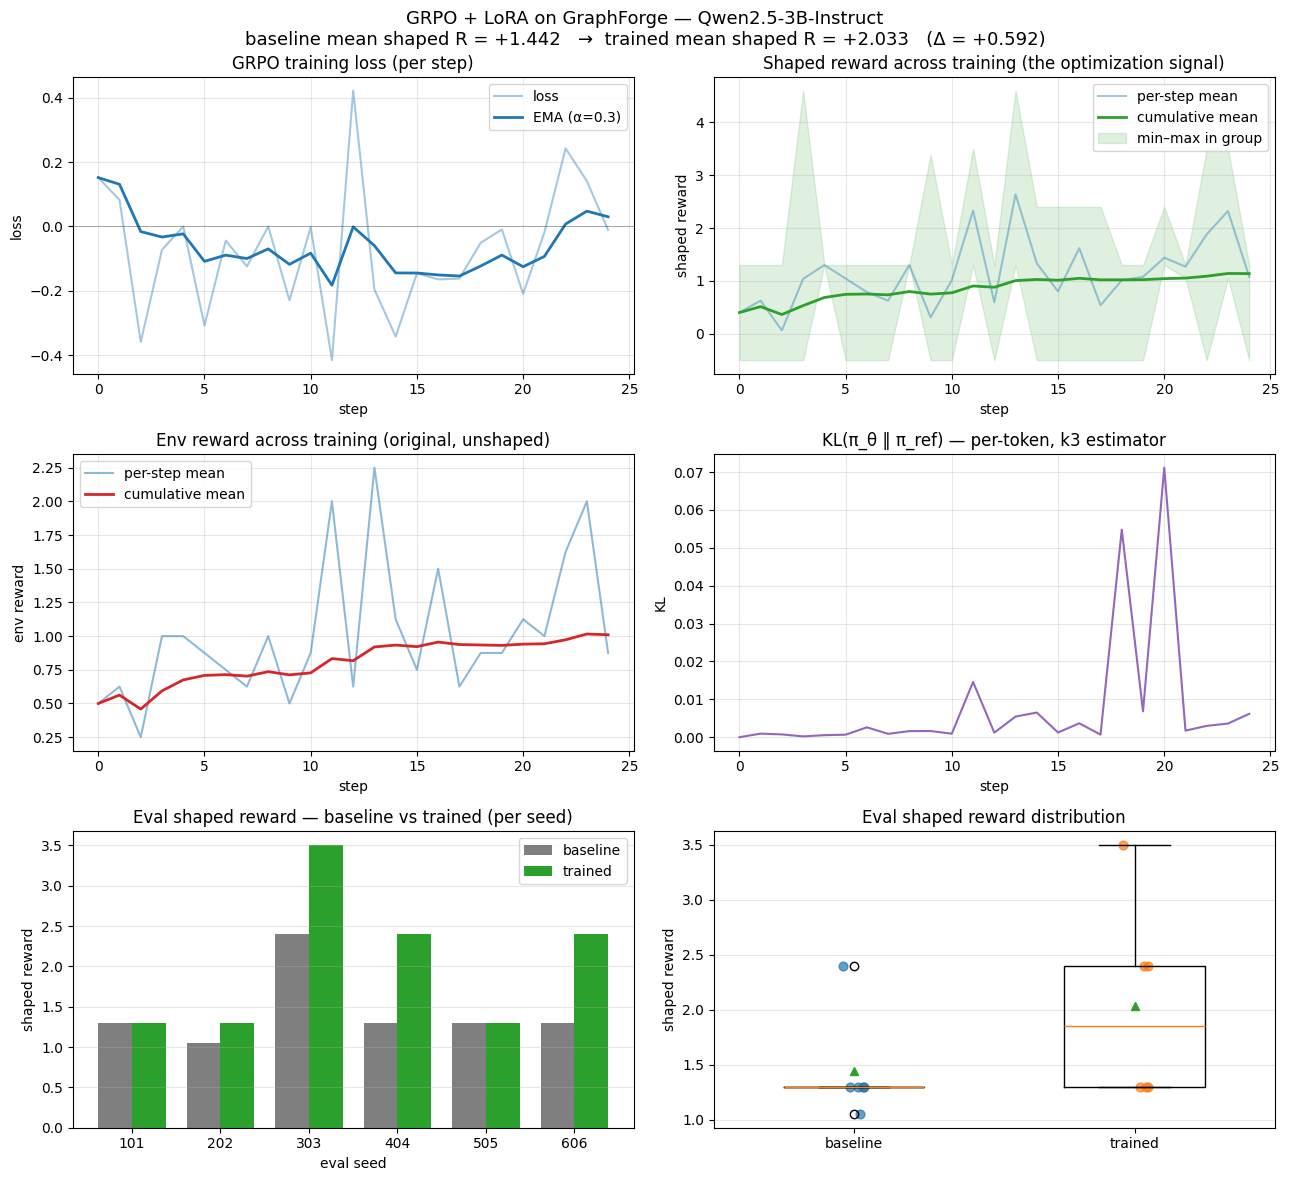


Figure saved to ./grpo_outputs_2/grpo_training_summary.png


In [13]:
def ema(values, alpha=0.3):
    out = []
    s = None
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
steps_ax = metrics_df["step"].values

# --- (1) training loss ---
ax = axes[0, 0]
ax.plot(steps_ax, metrics_df["loss"], alpha=0.4, label="loss")
ax.plot(steps_ax, ema(metrics_df["loss"].tolist(), 0.3), color="C0", lw=2, label="EMA (α=0.3)")
ax.axhline(0, color="k", lw=0.5, alpha=0.4)
ax.set_title("GRPO training loss (per step)")
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.legend(); ax.grid(alpha=0.3)

# --- (2) mean shaped reward + cumulative mean ---
ax = axes[0, 1]
ax.plot(steps_ax, metrics_df["mean_shaped_reward"], alpha=0.4, label="per-step mean")
cum = metrics_df["mean_shaped_reward"].expanding().mean()
ax.plot(steps_ax, cum, color="C2", lw=2, label="cumulative mean")
ax.fill_between(
    steps_ax,
    metrics_df["min_shaped_reward"], metrics_df["max_shaped_reward"],
    alpha=0.15, color="C2", label="min–max in group",
)
ax.set_title("Shaped reward across training (the optimization signal)")
ax.set_xlabel("step"); ax.set_ylabel("shaped reward")
ax.legend(); ax.grid(alpha=0.3)

# --- (3) env reward (original signal) ---
ax = axes[1, 0]
ax.plot(steps_ax, metrics_df["mean_env_reward"], alpha=0.5, label="per-step mean")
cum_env = metrics_df["mean_env_reward"].expanding().mean()
ax.plot(steps_ax, cum_env, color="C3", lw=2, label="cumulative mean")
ax.set_title("Env reward across training (original, unshaped)")
ax.set_xlabel("step"); ax.set_ylabel("env reward")
ax.legend(); ax.grid(alpha=0.3)

# --- (4) KL to ref ---
ax = axes[1, 1]
ax.plot(steps_ax, metrics_df["kl"], color="C4")
ax.set_title("KL(π_θ ‖ π_ref) — per-token, k3 estimator")
ax.set_xlabel("step"); ax.set_ylabel("KL")
ax.grid(alpha=0.3)

# --- (5) baseline vs trained: per-seed paired bars ---
ax = axes[2, 0]
merged = baseline_df.merge(
    trained_df, on="seed", suffixes=("_base", "_trained"),
)
x = np.arange(len(merged))
w = 0.38
ax.bar(x - w/2, merged["shaped_reward_base"],    width=w, label="baseline",  color="C7")
ax.bar(x + w/2, merged["shaped_reward_trained"], width=w, label="trained",   color="C2")
ax.set_xticks(x); ax.set_xticklabels(merged["seed"])
ax.set_title("Eval shaped reward — baseline vs trained (per seed)")
ax.set_xlabel("eval seed"); ax.set_ylabel("shaped reward")
ax.axhline(0, color="k", lw=0.5)
ax.legend(); ax.grid(alpha=0.3, axis="y")

# --- (6) distribution ---
ax = axes[2, 1]
data = [baseline_df["shaped_reward"].values, trained_df["shaped_reward"].values]
ax.boxplot(data, labels=["baseline", "trained"], showmeans=True, widths=0.5)
for i, arr in enumerate(data, start=1):
    ax.scatter(np.full_like(arr, i, dtype=float) + np.random.uniform(-0.05, 0.05, len(arr)),
               arr, alpha=0.7, s=40)
ax.set_title("Eval shaped reward distribution")
ax.set_ylabel("shaped reward")
ax.grid(alpha=0.3, axis="y")

fig.suptitle(
    f"GRPO + LoRA on GraphForge — Qwen2.5-3B-Instruct\n"
    f"baseline mean shaped R = {baseline_summary['mean_shaped_reward']:+.3f}   "
    f"→  trained mean shaped R = {trained_summary['mean_shaped_reward']:+.3f}   "
    f"(Δ = {trained_summary['mean_shaped_reward'] - baseline_summary['mean_shaped_reward']:+.3f})",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "grpo_training_summary.png"), dpi=140, bbox_inches="tight")
plt.show()

print(f"\nFigure saved to {os.path.join(OUT_DIR, 'grpo_training_summary.png')}")

## 15. Quantitative summary table

In [14]:
summary_table = pd.DataFrame([
    {
        "phase": "baseline (untrained)",
        "n_episodes":         baseline_summary["n_episodes"],
        "mean_env_reward":    round(baseline_summary["mean_env_reward"],    4),
        "mean_shaped_reward": round(baseline_summary["mean_shaped_reward"], 4),
        "mean_mutations":     round(baseline_summary["mean_mutations"],     2),
        "mean_turns":         round(baseline_summary["mean_turns"],         2),
    },
    {
        "phase": "trained (after GRPO+LoRA)",
        "n_episodes":         trained_summary["n_episodes"],
        "mean_env_reward":    round(trained_summary["mean_env_reward"],     4),
        "mean_shaped_reward": round(trained_summary["mean_shaped_reward"],  4),
        "mean_mutations":     round(trained_summary["mean_mutations"],      2),
        "mean_turns":         round(trained_summary["mean_turns"],          2),
    },
])
summary_table.to_csv(os.path.join(OUT_DIR, "baseline_vs_trained.csv"), index=False)
summary_table

,phase,n_episodes,mean_env_reward,mean_shaped_reward,mean_mutations,mean_turns
0,baseline (untrained),6,1.1667,1.4417,1.17,2.33
1,trained (after GRPO+LoRA),6,1.6667,2.0333,1.67,2.17


## 16. Inspect a trained-model rollout

Sanity check — print the actual mutations the trained policy produces on one of the eval seeds. You should see well-formed `<tool_call>` blocks and (with luck) Python that parses.

In [15]:
with GraphForgeASTEnv(base_url=SPACE_URL).sync() as env:
    print("=" * 72)
    print("TRAINED MODEL — single rollout on EVAL_SEEDS[0]")
    print("=" * 72)
    r = rollout(env, seed=EVAL_SEEDS[0], do_sample=True,
                temperature=EVAL_TEMPERATURE, max_turns=MAX_TURNS, verbose=True)

print(f"\nQuery     : {r['query']}")
print(f"Done      : {r['done']}")
print(f"Turns     : {r['n_turns']}")
print(f"Mutations : {r['n_mutations']}")
print(f"Env R     : {r['env_reward']:+.4f}")
print(f"Shaped R  : {r['shaped_reward']:+.4f}")

TRAINED MODEL — single rollout on EVAL_SEEDS[0]
  [t1] get_neighbors  Added 2 node(s) to context
  [t2] no tool call → forcing submit

Query     : Refactor the entire DecisionTree class to support multi-dimensional input featur
Done      : True
Turns     : 2
Mutations : 0
Env R     : +0.0000
Shaped R  : -0.5000


## Notes & links

**Submission materials**
- 🤗 **Hugging Face Space (environment):** [TarunGopinath/OpenENV-GraphForge](https://huggingface.co/spaces/TarunGopinath/OpenENV-GraphForge)
- 📄 **README** in the same Space, with the writeup, motivation, results, and links to slides / blog / video.
- 📊 **Run artifacts** are written to `./grpo_outputs/` — `train_metrics.csv`, `grpo_training_summary.png`, `baseline_vs_trained.csv`, plus the saved LoRA adapter.

**Design choices**

- *Why shaped rewards?* With only G=4 rollouts and a 3B base model, the env's terminal reward is often 0 across the entire group → zero advantage → no gradient. Shaping adds dense bonuses (mutation count, parse rate) that correlate with real progress without flipping signs. If you scale up to G=16+ or train longer, you can drop shaping; `KL_COEF` already keeps you near the base distribution.
- *Why `disable_adapter` as ref?* Saves an entire copy of weights in VRAM. The frozen base inside the PEFT-wrapped model *is* the reference; PEFT just bypasses the LoRA branches when the adapter is disabled.
- *Why Unsloth + a custom GRPO loop?* TRL's `GRPOTrainer.rollout_func` (added Feb 2026) was built for stateless reward functions; integrating a stateful multi-turn env with tool calls between policy generations is still rough. Unsloth's `FastLanguageModel` gives the speed/VRAM win without dictating the trainer, so the multi-turn rollout stays straightforward and correct.
- *Why per-turn backward?* See the comments in the loss cell. Summing the loss across all G·T turns first would keep every turn's activations alive simultaneously and OOM on a Colab GPU. Per-turn backward is mathematically identical and ~10× lower peak memory.

**Scaling up**
- `NUM_GRPO_STEPS=100`, `GROUP_SIZE=8`, `MAX_TURNS=10` is a much stronger demonstration; runs in ~1 hour on an A100.
- For multi-GPU: Unsloth supports DDP. Or run a vLLM rollout worker on a second GPU and sync LoRA weights between GRPO steps for ~3-5× faster sampling.
- For a tighter Colab T4 budget: `GROUP_SIZE=2`, `MAX_TURNS=4`, `MAX_NEW_TOKENS=256`.
